# 심층 신경망 훈련하기

------

고해상도 이미지 등 복잡한 문제를 다룰 때 매우 깊은 심층 신경망을 훈련해야 할 수 있다.

심층 신경망 훈련 도중 다음과 같은 상황을 마주할 수 있다.

* 까다로운 그레디언트 소실 또는 그레디언트 폭주 문제에 직면할 수 있음. 심층 신경망 아래쪽으로 갈수록 그레디언트가 점점 작아지거나 커지는 현상

* 대규모 신경망을 훈련하기 위한 데이터가 충분치 않거나 레이블을 만드는 데 비용이 많이 듬

* 훈련이 극단적으로 느려짐

* 수백만 개의 파라미터를 가진 모델은 과적합될 수 있음

## 그레디언트 소실, 폭주 문제

-----

역전파 알고리즘이 하위층(입력층 근처)으로 진행될수록 그레디언트가 작아지거나 (소실) 커지는 현상 (폭주)은 훈련을 어렵게 한다.

의심되는 원인으로서 많이 사용되는 로지스틱 시그모이드 활성화 함수와, 표준정규분포 가중치 초기화 방법이 거론된다.

- 로지스틱 함수는 입력이 양수나 음수로 커지면 기울기가 0에 매우 가까워진다.

- 역전파가 될 때, 전달될 그레디언트가 거의 없고, 조금 있는 그레디언트는 최상위층으로부터 진행되며 점점 약해진다.

### 가중치 초기화 방법

이전에 살펴봤듯이 모델을 생성할 때 가중치는 랜덤으로 초기화된다.

로지스틱 함수를 이용할 때, 각 층의 연결 가중치를 아래의 식을 이용하여 랜덤 초기화하면 그레디언트 문제를 완화할 수 있다.

이를 Xavier(Glorot) initialization라고 한다.

$$ \text{정규분포 : 평균이 0이고, 표준편차 } \sigma = \sqrt{\frac{1}{\text{fan}_{\mathrm{avg}}}} $$
$$ \text{혹은, 균등분포 : between } -r \text{ and } r, \text{ with } r = \sqrt{\frac{3}{\text{fan}_{\mathrm{avg}}}} $$

여기서 $\text{fan}_{\mathrm{avg}}$은 층의 입력과 출력의 연결 개수인 $\text{fan}_{\mathrm{in}}$과 $\text{fan}_{\mathrm{out}}$의 평균이다.

그 외에 다음과 같은 [초기화 전략](https://keras.io/api/layers/initializers/)들이 있다.
  
| 초기화 전략 | 활성화 함수 | 정규분포 분산 |
|--|--|--|
| Glorot | linear, 하이퍼볼릭 탄젠트, 로지스틱, 소프트맥스 | $1/\text{fan}_{\mathrm{avg}}$ |
| He | ReLU 함수와 그 변종들 | $2 / \text{fan}_{\mathrm{in}}$ |
| LeCun | SELU | $1/\text{fan}_{\mathrm{in}}$ |

케라스는 기본적으로 균등분포의 글로럿 초기화를 사용한다. 

다음과 같이 층을 만들 때, ```kernel_initializer="he_uniform"```처럼 문자열로 인자를 입력하거나, [클래스 객체](https://keras.io/2/api/layers/initializers/)를 전달하여 바꾸어 쓸 수 있다. 

- ```keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal")```

- `keras.layers.Dense(10, activation=relu, kernel_initializer=keras.initializers.HeNormal())`

한편, `keras.layers.Dense`의 기본값은 `kernel_initializer="glorot_uniform"`이다.

### 활성화 함수 문제

활성화 함수를 잘못 선택하면 그레디언트 소실이나 폭주로 이어질 수 있다.

초기에는 생물학적 뉴런과 비슷한 시그모이드 함수가 잘 작동할 것이라고 생각되었지만, ReLU 같은 활성화 함수가 심층 신경망에서 더 잘 작동하는 경향이 있다.

- 하지만 ReLU도 완벽하지 않고, 죽은 ReLU 문제가 알려져 있다. 

- 훈련 중 일부 뉴런이 0만 출력하는 현상이다. 

이 문제를 해결하기 위해 LeakyReLU, ELU, SELU 같은 변종을 사용한다.

$$ \mathrm{LeakyReLU}_{\alpha}(z) = \max(\alpha z, z) $$

$$ \mathrm{ELU}_{\alpha}(z) = 
\left\{ \begin{array}{ll} \alpha (\exp(z) - 1) & z < 0 \\
z & z \geq 0 \end{array} \right.
$$

$$ \mathrm{SELU}_{\alpha}(z) =
\left\{ \begin{array}{ll}
\lambda \alpha (\exp(z) - 1) & \text{if } z < 0 \\
\lambda z & \text{if } z \geq 0 \\
\end{array}
\right.
$$

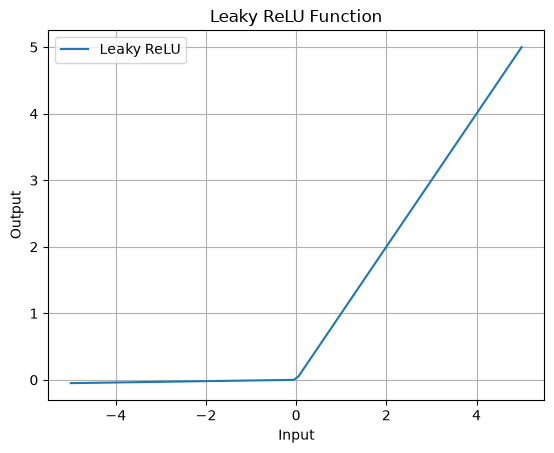

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

x_values = np.linspace(-5, 5, 100)
y_values = leaky_relu(x_values)

plt.plot(x_values, y_values, label='Leaky ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Leaky ReLU Function')
plt.legend()
plt.grid(True)
plt.show()

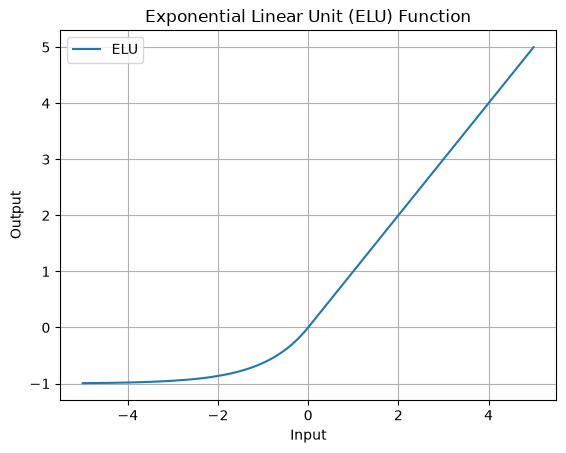

In [2]:
def elu(x, alpha=1.0):
    return np.where(x < 0, alpha * (np.exp(x) - 1), x)

x_values = np.linspace(-5, 5, 100)
y_values = elu(x_values)

plt.plot(x_values, y_values, label='ELU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Exponential Linear Unit (ELU) Function')
plt.legend()
plt.grid(True)
plt.show()

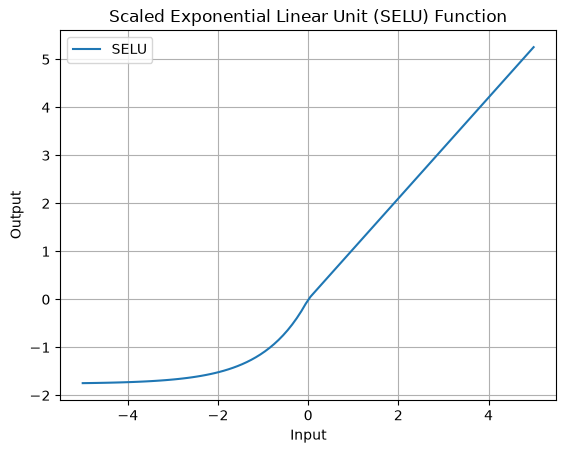

In [3]:
def selu(x, alpha=1.67326, scale=1.0507):
    return scale * np.where(x > 0, x, alpha * (np.exp(x) - 1))

x_values = np.linspace(-5, 5, 100)
y_values = selu(x_values)

# 그래프 그리기
plt.plot(x_values, y_values, label='SELU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Scaled Exponential Linear Unit (SELU) Function')
plt.legend()
plt.grid(True)
plt.show()

케라스에서 [LeakyReLU](https://keras.io/api/layers/activation_layers/leaky_relu/)를 사용하려면 다음과 같이 코드를 작성한다. 즉, Dense 층의 뒤에 LeakyReLU 층을 추가한다.

```
model = keras.models.Sequential([
  [...]
  keras.layers.Dense(10, kernel_initializer="he_normal"),
  keras.layers.LeakyReLU(negative_slope=0.2)
  [...]
])
```

SELU 함수를 사용하려면 다음과 같이 코드를 작성한다.

``` layer = keras.layers.Dense(10, activation="selu", kernel_initializer="lecun_normal") ```

`keras.datasets.fashion_mnist`를 이용하여 예제를 실행해 본다.

In [4]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [6]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [7]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [8]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/10


1719/1719 - 7s - 4ms/step - accuracy: 0.5852 - loss: 1.2791 - val_accuracy: 0.7030 - val_loss: 0.8848


Epoch 2/10


1719/1719 - 10s - 6ms/step - accuracy: 0.7315 - loss: 0.7991 - val_accuracy: 0.7628 - val_loss: 0.7171


Epoch 3/10


...

1719/1719 - 6s - 4ms/step - accuracy: 0.8239 - loss: 0.5202 - val_accuracy: 0.8288 - val_loss: 0.5057


Epoch 9/10


1719/1719 - 6s - 4ms/step - accuracy: 0.8276 - loss: 0.5072 - val_accuracy: 0.8316 - val_loss: 0.4922


Epoch 10/10


1719/1719 - 6s - 3ms/step - accuracy: 0.8313 - loss: 0.4964 - val_accuracy: 0.8372 - val_loss: 0.4842


In [9]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [10]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [11]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/10


1719/1719 - 7s - 4ms/step - accuracy: 0.6322 - loss: 1.3110 - val_accuracy: 0.7494 - val_loss: 0.8772


Epoch 2/10


1719/1719 - 7s - 4ms/step - accuracy: 0.7496 - loss: 0.7907 - val_accuracy: 0.7782 - val_loss: 0.7011


Epoch 3/10


...

1719/1719 - 6s - 4ms/step - accuracy: 0.8252 - loss: 0.5164 - val_accuracy: 0.8386 - val_loss: 0.4959


Epoch 9/10


1719/1719 - 7s - 4ms/step - accuracy: 0.8302 - loss: 0.5027 - val_accuracy: 0.8440 - val_loss: 0.4848


Epoch 10/10


1719/1719 - 6s - 4ms/step - accuracy: 0.8332 - loss: 0.4916 - val_accuracy: 0.8436 - val_loss: 0.4736


### 배치 정규화

Layer에서 활성화 함수를 통과하기 전이나 후에 정규화 연산을 추가하는 것을 배치 정규화라고 한다.

- 각 유닛의 출력을 미니배치 단위로 정규화한다.

- 먼저 입력값을 평균 0, 분산 1로 정규화한 후, 최적의 새로운 평균과 분산으로 재조정하는 방식.

과정의 순서는 다음과 같다. Layer의 각 유닛 별로 계산이 이루어진다.

* 미니배치별로 배치정규화층에 사용될 입력값의 표본평균($\mu_B$)과 표본표준편차($\sigma_B$)를 계산한다.

* 미니배치별 표본평균과 표본표준편차를 이용하여 입력값을 표준정규화한다. 

   * 하지만 정규화된 값들은 평균 0과 표준편차 1의 분포를 가지는데 이러한 제약은 뉴럴 네트워크의 성능을 제한할 수 있다. <br><br>

* 이에 훈련 가능한 스케일 파라미터 $\mathbf{\gamma}$와 오프셋 파라미터 $\mathbf{\beta}$를 추가 도입하여 네트워크의 성능을 향상하도록 한다.

$$ \mathbf{\gamma} \circ \mathbf{\hat x} + \mathbf{\beta} $$

* 여기서 $\mathbf{\hat x}$은 표준정규화된 입력값이다.

* 한편, $\mu_B$와 $\sigma^2_B$의 값은 이동평균과 이동분산의 형식으로 기록하여 저장한다. (예: `moving_mean = momentum * moving_mean + (1 - momentum) * batch_mean`, `moving_variance = momentum * moving_variance + (1 - momentum) * batch_variance`)   

얼핏 보기에는 표준 정규화 후에 다시 $\mathbf{\gamma}$와 $\mathbf{\beta}$로 rescaling하는 과정이 의미가 없어 보일 수 있다.

- 하지만 학습 가능한 scale $\mathbf{\gamma}$와 offset $\mathbf{\beta}$를 적용하는 과정이라고 생각하면 좋다.

- 이 과정을 복잡한 네트워크 구조가 아닌 $\mathbf{\gamma}$와 $\mathbf{\beta}$만으로 훈련하여 익히게 하면 좋은 성능 향상을 기대할 수 있다고 한다.

한편 테스트 셋에서의 정규화는 훈련 데이터에서 배치 별로 계산한 표본평균과 표본표준편차를 이동평균(moving average) 낸 값을 사용한다.

- 테스트 시에는 배치 크기가 훈련 시와 다를 수 있으며, 심지어 하나의 샘플만 입력될 수도 있기 때문

배치 정규화는 학습을 안정화하고 더 큰 학습률을 사용할 수 있게 도와주는 경우가 많다.

케라스에서는 [`BatchNormalization`](https://keras.io/api/layers/normalization_layers/batch_normalization/)을 이용하여 배치 정규화를 구현한다.

In [12]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [14]:
bn1 = model.layers[1]
[(var.name, var.trainable) for var in bn1.variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

In [15]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [16]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/10


1719/1719 - 8s - 5ms/step - accuracy: 0.7242 - loss: 0.8225 - val_accuracy: 0.8208 - val_loss: 0.5445


Epoch 2/10


1719/1719 - 7s - 4ms/step - accuracy: 0.8022 - loss: 0.5708 - val_accuracy: 0.8442 - val_loss: 0.4675


Epoch 3/10


...

1719/1719 - 8s - 4ms/step - accuracy: 0.8553 - loss: 0.4126 - val_accuracy: 0.8718 - val_loss: 0.3700


Epoch 9/10


1719/1719 - 8s - 4ms/step - accuracy: 0.8576 - loss: 0.4024 - val_accuracy: 0.8740 - val_loss: 0.3635


Epoch 10/10


1719/1719 - 8s - 4ms/step - accuracy: 0.8593 - loss: 0.3965 - val_accuracy: 0.8752 - val_loss: 0.3578


훈련 후 계산된 이동평균과 이동분산

In [17]:
bn_layer = model.layers[5]
print("Moving mean:", bn_layer.moving_mean.numpy()[:10])
print("Moving variance:", bn_layer.moving_variance.numpy()[:10])

Moving mean: [0.48872682 0.73966897 0.44379526 0.6115114  0.667123   0.52992254
 0.6300083  0.7989501  0.70876795 0.45439625]
Moving variance: [0.5096685  1.2145369  0.41182923 1.1198976  0.76590216 0.48416263
 0.8719058  1.1825052  0.897778   0.47770643]


In [18]:
#### 활성화 함수 전에 사용하는 방법

model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dense(100, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │       235,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,946 (1.03 MB)

 Trainable params: 268,578 (1.02 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [20]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [21]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid), verbose=2)

Epoch 1/10


1719/1719 - 9s - 5ms/step - accuracy: 0.6695 - loss: 1.0510 - val_accuracy: 0.7886 - val_loss: 0.6724


Epoch 2/10


1719/1719 - 7s - 4ms/step - accuracy: 0.7823 - loss: 0.6738 - val_accuracy: 0.8162 - val_loss: 0.5556


Epoch 3/10


...

1719/1719 - 7s - 4ms/step - accuracy: 0.8437 - loss: 0.4557 - val_accuracy: 0.8606 - val_loss: 0.4028


Epoch 9/10


1719/1719 - 7s - 4ms/step - accuracy: 0.8461 - loss: 0.4462 - val_accuracy: 0.8636 - val_loss: 0.3934


Epoch 10/10


1719/1719 - 8s - 5ms/step - accuracy: 0.8512 - loss: 0.4318 - val_accuracy: 0.8668 - val_loss: 0.3861


### 그레디언트 클리핑

그레디언트 폭주 문제를 완화하는 방법으로 역전파 수행 시 그레디언트가 일정 임계값을 넘지 못하도록 하는 것이다.

이 작업은 optimizer를 설정할 때 이루어진다.

```optimizer = keras.optimizers.SGD(clipvalue=1.0)```

```optimizer = keras.optimizers.SGD(clipnorm=1.0)```

## 훈련된 층 재사용하기

-----

아주 큰 심층 신경망(DNN)을 처음부터 훈련하는 것은 많은 시간과 자원을 필요로 한다.

하지만 비슷한 유형의 문제라면, 이미 학습된 모델의 하위층(lower layers) 이 일반적인 특징(feature)을 잘 포착하고 있으므로 이를 재사용(reuse) 하는 것이 가능하다.


이러한 접근법을 전이 학습(Transfer Learning) 이라고 한다. (상위 층은 문제별로 특화되어 덜 유용함)

### 전이 학습의 핵심 아이디어
- **하위층**: 엣지, 색상, 질감 등 일반적인 특징을 추출 → 여러 문제에 공통적으로 유용함  
- **상위층**: 문제별 세부 패턴에 특화 → 새로운 문제에서는 덜 유용할 수 있음  

먼저 재사용할 층을 동결하고 새로운 출력층을 학습한다. 이후 필요하면 재사용한 층 일부의 동결을 해제하고 작은 학습률로 미세 조정한다.

### 절차
1. 사전 학습된(pre-trained) 모델 선택
   - 유사한 데이터셋으로 학습된 모델을 불러온다. <br><br>

2. 하위층의 가중치 동결(freeze) 
   - 이미 학습된 일반적 특징을 유지하기 위해 하위층의 가중치를 고정한다.  <br><br>

3. 상위층 재구성 및 학습
   - 새로운 문제에 맞는 출력층(output layer)이나 몇 개의 은닉층(hidden layers)을 추가하고 학습한다.  <br><br>

4. 미세 조정(fine-tuning) 
   - 필요하다면 상위 몇 개 층의 동결을 해제하고 역전파로 가중치를 조정하여 성능 향상을 시도한다.<br><br>

### 케라스를 이용한 전이 학습

패션 MNIST 훈련 세트를 두 개로 나눈다.

* `X_train_A`: 샌달과 셔츠(클래스 5와 6)을 제외한 모든 이미지
* `X_train_B`: 샌달과 셔츠 이미지 중 처음 200개만 가진 작은 훈련 세트


A 세트(8개의 클래스를 가진 분류 문제)에서 모델을 훈련하고 이를 재사용하여 B 세트(이진 분류)를 해결해 보자. 

- A 세트의 클래스(스니커즈, 앵클 부츠, 코트, 티셔츠 등)가 B 세트에 있는 클래스(샌달과 셔츠)와 조금 비슷함. 

In [22]:
def split_dataset(X, y):
    y_5_or_6 = (y == 5) | (y == 6) # sandals or shirts
    y_A = y[~y_5_or_6]
    y_A[y_A > 6] -= 2 # class indices 7, 8, 9 should be moved to 5, 6, 7
    y_B = (y[y_5_or_6] == 6).astype(np.float32) # binary classification task: is it a shirt (class 6)?
    return ((X[~y_5_or_6], y_A),
            (X[y_5_or_6], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

먼저 `model_A`를 만들어 A set을 이용해 훈련하겠다.

In [23]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Input(shape=[28, 28]))
model_A.add(keras.layers.Flatten())
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu", kernel_initializer="lecun_normal"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

In [24]:
model_A.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,158 (1.05 MB)

 Trainable params: 276,158 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                metrics=["accuracy"])

In [26]:
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                    validation_data=(X_valid_A, y_valid_A), verbose=2)

Epoch 1/20


1375/1375 - 6s - 4ms/step - accuracy: 0.8289 - loss: 0.5495 - val_accuracy: 0.8792 - val_loss: 0.3707


Epoch 2/20


1375/1375 - 5s - 4ms/step - accuracy: 0.8832 - loss: 0.3470 - val_accuracy: 0.8941 - val_loss: 0.3223


Epoch 3/20


...

1375/1375 - 5s - 4ms/step - accuracy: 0.9239 - loss: 0.2238 - val_accuracy: 0.9173 - val_loss: 0.2411


Epoch 19/20


1375/1375 - 5s - 4ms/step - accuracy: 0.9249 - loss: 0.2217 - val_accuracy: 0.9200 - val_loss: 0.2410


Epoch 20/20


1375/1375 - 5s - 4ms/step - accuracy: 0.9252 - loss: 0.2190 - val_accuracy: 0.9170 - val_loss: 0.2469


In [27]:
model_A.save("my_model_A.keras")

model B는 자체 훈련으로 생성해 본다.

추후에 전이 학습된 결과와 비교해 볼 수 있다.

In [28]:
model_B = keras.models.Sequential()
model_B.add(keras.layers.Input(shape=[28, 28]))
model_B.add(keras.layers.Flatten())
for n_hidden in (300, 100, 50, 50, 50):
    model_B.add(keras.layers.Dense(n_hidden, activation="selu", kernel_initializer="lecun_normal"))
model_B.add(keras.layers.Dense(1, activation="sigmoid"))

In [29]:
model_B.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,801 (1.05 MB)

 Trainable params: 275,801 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_B.compile(loss="binary_crossentropy",
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                metrics=["accuracy"])

In [31]:
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B), verbose=2)

Epoch 1/20


7/7 - 1s - 160ms/step - accuracy: 0.4650 - loss: 0.7558 - val_accuracy: 0.6623 - val_loss: 0.6167


Epoch 2/20


7/7 - 0s - 29ms/step - accuracy: 0.7000 - loss: 0.5607 - val_accuracy: 0.7556 - val_loss: 0.5004


Epoch 3/20


...

7/7 - 0s - 31ms/step - accuracy: 0.9900 - loss: 0.1065 - val_accuracy: 0.9777 - val_loss: 0.1333


Epoch 19/20


7/7 - 0s - 30ms/step - accuracy: 0.9950 - loss: 0.1007 - val_accuracy: 0.9787 - val_loss: 0.1286


Epoch 20/20


7/7 - 0s - 35ms/step - accuracy: 0.9950 - loss: 0.0960 - val_accuracy: 0.9807 - val_loss: 0.1241


`model_B_on_A`를 생성하는데, `model_B_on_A`는 `model_A`의 구조와 학습된 가중치를 복사하여 사용한다. 두 모델은 실제 레이어 객체를 공유하지 않는다.

즉, 전이 학습을 적용.

아래 코드에서 `model_A`의 마지막 층을 제외하고 나머지를 가져다가 사용한다.

- 하위층(feature extractor) 재사용

In [32]:
model_A = keras.models.load_model("my_model_A.keras")

# model_A.layers를 그대로 쓰면 레이어를 공유하게 되어 model_B_on_A를 훈련할 때
# model_A도 함께 바뀐다. clone_model()로 구조와 가중치를 복제해 독립된 사본을 먼저 만든다.
model_A_clone = keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

model_B_on_A = keras.models.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))


`model_A.layers[:-1]`을 그대로 가져다 쓰면 `model_B_on_A`와 `model_A`가 레이어를 실제로 공유하게 되어, `model_B_on_A`를 훈련할 때 `model_A`의 가중치도 함께 바뀐다.

이를 피하기 위해 위 코드에서는 ```clone_model()```로 `model_A`의 구조를 복제하고 가중치를 복사한 `model_A_clone`을 만들었고, `model_B_on_A`는 원본이 아니라 이 복제본의 레이어로부터 구성했다.


이제 `model_B_on_A`를 훈련할 수 있는데, 새로운 출력층이 랜덤하게 초기화되었으므로, 큰 오차를 생성할 수 있음.

큰 오차 그레디언트가 재사용된 가중치를 망치지 않도록, 처음 몇 번의 에포크 동안은 재사용된 층을 동결하고 새로운 층에 적절한 가중치를 학습할 시간을 준다.

In [33]:
# 맨 위 출력층을 제외한 모든 층의 가중치를 동결
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                     metrics=["accuracy"])

모델을 몇 번 훈련하고, 재사용된 층의 동결을 해제한 뒤, 다시 컴파일한 다음, 훈련을 계속한다.

일반적으로 재사용된 층의 동결을 해제한 후 학습률을 낮추는 것이 좋다.

In [34]:
# 하위층 동결 후 상위층만 학습
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B), verbose=2)

# 하위층 동결 해제
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(learning_rate=1e-4),
                     metrics=["accuracy"])

# 전체 모델 학습
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B), verbose=2)

Epoch 1/4


7/7 - 1s - 151ms/step - accuracy: 0.9750 - loss: 0.2574 - val_accuracy: 0.9604 - val_loss: 0.2687


Epoch 2/4


7/7 - 0s - 31ms/step - accuracy: 0.9800 - loss: 0.2495 - val_accuracy: 0.9604 - val_loss: 0.2614


Epoch 3/4


...

7/7 - 0s - 48ms/step - accuracy: 0.9850 - loss: 0.1865 - val_accuracy: 0.9757 - val_loss: 0.2019


Epoch 15/16


7/7 - 0s - 33ms/step - accuracy: 0.9850 - loss: 0.1840 - val_accuracy: 0.9757 - val_loss: 0.1992


Epoch 16/16


7/7 - 0s - 34ms/step - accuracy: 0.9850 - loss: 0.1813 - val_accuracy: 0.9767 - val_loss: 0.1967


In [35]:
model_B.evaluate(X_test_B, y_test_B, verbose=0, return_dict=True)

{'accuracy': 0.9835000038146973, 'loss': 0.12023942917585373}

In [36]:
model_B_on_A.evaluate(X_test_B, y_test_B, verbose=0, return_dict=True)

{'accuracy': 0.9815000295639038, 'loss': 0.19689053297042847}

## 고속 옵티마이저

-----

아주 큰 심층 신경망의 훈련 속도는 심각하게 느릴 수 있다.  

표준적인 경사 하강법 외에 속도 향상을 위해 특별하게 구현된 옵티마이저들을 이용할 수 있다.  

이러한 옵티마이저들에 대해 자세히 다루지는 않겠지만 대략 어떤 종류의 것들이 있는지 살펴본다.

### 모멘텀 옵티마이저

일반적인 경사 하강법은 그레디언트가 작으면 천천히 수렴한다.  

모멘텀 옵티마이저는 이전 그레디언트의 이동 방향을 누적하여 일관된 방향의 이동은 가속하고, 방향이 자주 바뀌는 진동은 줄인다.

보통 ```momentum=0.9``` 정도로 설정하면 잘 작동한다고 한다.

In [37]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

### 네스테로프 가속 경사

모멘텀 옵티마이저를 더 향상시킨 방법이다.

In [38]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

### AdaGrad

AdaGrad는 경사 하강법의 최적화 알고리즘 중 하나로 각 parameter들에 대해 학습률을 조정하여 성능을 향상시킨다.

각 parameter의 과거 gradient 제곱을 누적하고, 누적값이 클수록 해당 parameter의 학습률을 줄인다.

[`keras.optimizers.Adagrad`](https://keras.io/api/optimizers/adagrad/)를 이용한다.

In [39]:
optimizer = keras.optimizers.Adagrad(learning_rate=0.001)

### RMSProp

AdaGrad는 학습률이 계속 감소하여 학습이 너무 일찍 느려질 수 있다. RMSProp은 최근 gradient 제곱의 이동평균을 사용하여 이 문제를 완화한다.

RMSProp는 Root Mean Squared Propagation을 뜻한다.

[`keras.optimizers.RMSprop`](https://keras.io/api/optimizers/rmsprop/)를 이용한다.

In [40]:
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

### Adam 옵티마이저

Adam은 adaptive moment estimation을 뜻하며 모멘텀 최적화와 RMSProp을 합친 개념이다.

많은 신경망 학습에서 효과적으로 사용된다고 알려져 있으며, 다양한 하이퍼파라미터 설정에 덜 민감하다고 한다.

[`keras.optimizers.Adam`](https://keras.io/api/optimizers/adam/)을 이용한다.

In [41]:
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

### Adamax 옵티마이저

Adam의 변종으로 만약 Adam이 잘 작동하지 않는다면 시도해 볼만한 옵티마이저이다.

In [42]:
optimizer = keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

### Nadam 옵티마이저

마찬가지로 Adam의 변종으로 종종 Adam보다 조금 더 빠르게 수렴한다고 알려져 있다.

In [43]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

## 학습률 스케줄링

----

학습률을 너무 크게 잡으면 훈련이 발산할 수 있고, 너무 작게 잡으면 수렴 시간이 오래 걸릴 것이다.

큰 학습률로 시작하고 학습 속도가 느려질 때 학습률을 낮추는 전략을 취할 수 있다.

훈련하는 동안 학습률을 감소시키는 학습 스케쥴에는 여러 가지가 있다.

### 거듭제곱 기반 스케줄링

반복횟수 $t$에 대해 학습률을 다음과 같이 정의한다.

$$\eta(t) = \frac{\eta_0}{(1 + t / s)^c}$$

케라스에서 학습률을 동적으로 조절하기 위해서는 [`keras.callbacks.LearningRateScheduler`](https://keras.io/api/callbacks/learning_rate_scheduler/)를 이용한다.

In [44]:
# 이미지 데이터를 표준화
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
pixel_stds = np.maximum(pixel_stds, 1e-7)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [45]:
def power_schedule(epoch, initial_lr = 0.01, decay_rate = 0.001, power = 1):
    return initial_lr / ((1 + decay_rate * epoch) ** power)

lr_scheduler = keras.callbacks.LearningRateScheduler(power_schedule)

In [46]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",optimizer = keras.optimizers.SGD(learning_rate=0.01), metrics=["accuracy"])

In [47]:
n_epochs = 25
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid), 
                    callbacks=[lr_scheduler], verbose=2)

Epoch 1/25


1719/1719 - 7s - 4ms/step - accuracy: 0.8307 - loss: 0.4856 - val_accuracy: 0.8556 - val_loss: 0.4199 - learning_rate: 0.0100


Epoch 2/25


1719/1719 - 6s - 4ms/step - accuracy: 0.8644 - loss: 0.3807 - val_accuracy: 0.8694 - val_loss: 0.3830 - learning_rate: 0.0100


Epoch 3/25


...

1719/1719 - 6s - 4ms/step - accuracy: 0.9472 - loss: 0.1515 - val_accuracy: 0.8892 - val_loss: 0.3374 - learning_rate: 0.0078


Epoch 24/25


1719/1719 - 6s - 4ms/step - accuracy: 0.9491 - loss: 0.1467 - val_accuracy: 0.8918 - val_loss: 0.3271 - learning_rate: 0.0076


Epoch 25/25


1719/1719 - 6s - 4ms/step - accuracy: 0.9507 - loss: 0.1428 - val_accuracy: 0.8908 - val_loss: 0.3458 - learning_rate: 0.0074


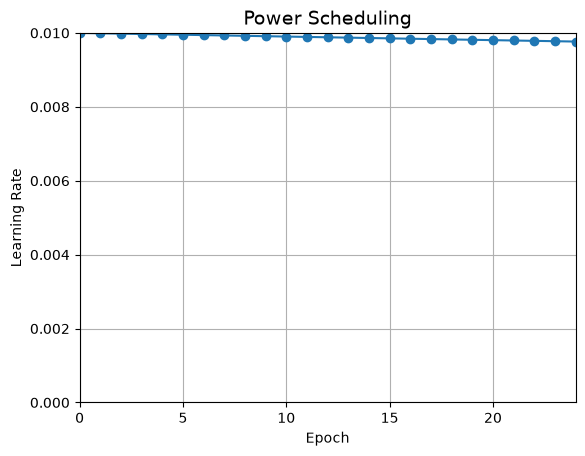

In [48]:
import math
import matplotlib.pyplot as plt

batch_size = 32
n_steps_per_epoch = math.ceil(len(X_train) / batch_size)
epochs = np.arange(n_epochs)

lrs = np.array([power_schedule(e) for e in epochs])

plt.plot(epochs, lrs,  "o-")
plt.axis([0, n_epochs - 1, 0, 0.01])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.grid(True)
plt.show()

### 지수 기반 스케줄링

비슷하게 지수 기반으로 감소하는 학습률 스케줄링을 사용할 수 있다.

```lr = lr0 * 0.1**(epoch / s)```

In [49]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1**(epoch / 20)

In [50]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 25

In [51]:
lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[lr_scheduler], verbose=2)

Epoch 1/25


1719/1719 - 10s - 6ms/step - accuracy: 0.7765 - loss: 0.7524 - val_accuracy: 0.8028 - val_loss: 0.7598 - learning_rate: 0.0100


Epoch 2/25


1719/1719 - 9s - 5ms/step - accuracy: 0.8049 - loss: 0.6333 - val_accuracy: 0.8206 - val_loss: 0.6747 - learning_rate: 0.0089


Epoch 3/25


...

1719/1719 - 8s - 5ms/step - accuracy: 0.9569 - loss: 0.1322 - val_accuracy: 0.8920 - val_loss: 0.5795 - learning_rate: 7.9433e-04


Epoch 24/25


1719/1719 - 8s - 5ms/step - accuracy: 0.9601 - loss: 0.1222 - val_accuracy: 0.8910 - val_loss: 0.5861 - learning_rate: 7.0795e-04


Epoch 25/25


1719/1719 - 8s - 5ms/step - accuracy: 0.9623 - loss: 0.1149 - val_accuracy: 0.8898 - val_loss: 0.6109 - learning_rate: 6.3096e-04


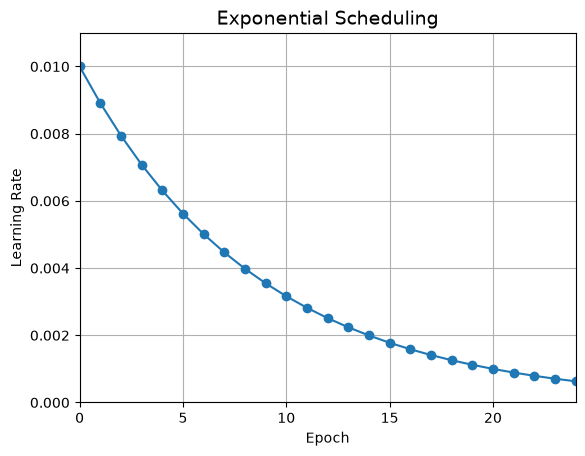

In [52]:
plt.plot(history.epoch, history.history["learning_rate"], "o-")
plt.axis([0, n_epochs - 1, 0, 0.011])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.grid(True)
plt.show()

그 외에

* 구간별 고정 스케줄링
* 성능 기반 스케줄링
* 1 사이클 스케줄링

Validation loss가 더 이상 감소하지 않으면 early stopping을 사용하여 학습을 종료할 수 있다.

## 과대적합 피하기

-----

### $\ell_1$과 $\ell_2$ 규제

선형 모델에서 했던 것처럼 신경망의 연결 가중치를 제한하기 위해  $\ell_2$ 규제를 사용하거나, 아예 일부 가중치를 0으로 만들기 위해  $\ell_1$ 규제를 적용할 수 있다.

규제를 적용한 경우 훈련 로그의 loss에는 cross-entropy와 regularization penalty가 함께 포함된다.

In [53]:
layer = keras.layers.Dense(100, activation="elu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=keras.regularizers.l2(0.01))
# or l1(0.1) for ℓ1 regularization with a factor of 0.1
# or l1_l2(0.1, 0.01) for both ℓ1 and ℓ2 regularization, with factors 0.1 and 0.01 respectively

In [54]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="elu",
                       kernel_initializer="he_normal",
                       kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(100, activation="elu",
                       kernel_initializer="he_normal",
                       kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(10, activation="softmax",
                       kernel_regularizer=keras.regularizers.l2(0.01))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid), verbose=2)

Epoch 1/2


1719/1719 - 10s - 6ms/step - accuracy: 0.8134 - loss: 1.6129 - val_accuracy: 0.8308 - val_loss: 0.7160


Epoch 2/2


1719/1719 - 8s - 5ms/step - accuracy: 0.8243 - loss: 0.7213 - val_accuracy: 0.8416 - val_loss: 0.6862


### 드롭아웃

드롭아웃은 심층 신경망에서 인기 있는 규제로 잘 작동된다고 입증되었다.

매 훈련 각 스텝에서 각 뉴런은 임시적으로 드롭아웃될 확률 $p$를 가진다.

* Dropout 비율은 보통 0.1에서 0.5 사이에서 시도하며, validation 성능을 이용하여 결정한다.

즉, 이번 훈련에는 무시되어도 다음 훈련에서는 활성화 될 수 있다.

훈련이 끝난 후에는 드롭아웃을 적용하지 않는다.

각 훈련에서 고유한 네트워크가 생성되는 것처럼 간주할 수 있다.

케라스에서는 [```keras.layers.Dropout```](https://keras.io/api/layers/regularization_layers/dropout/)을 이용해 구현한다.

`tf.keras.layers.Dropout(rate, noise_shape=None, seed=None, **kwargs)`

이 층은 훈련하는 동안 일부 입력을 랜덤하게 버린다 (0으로 설정).

그 다음 남은 입력을 $1-p$로 나눈다.

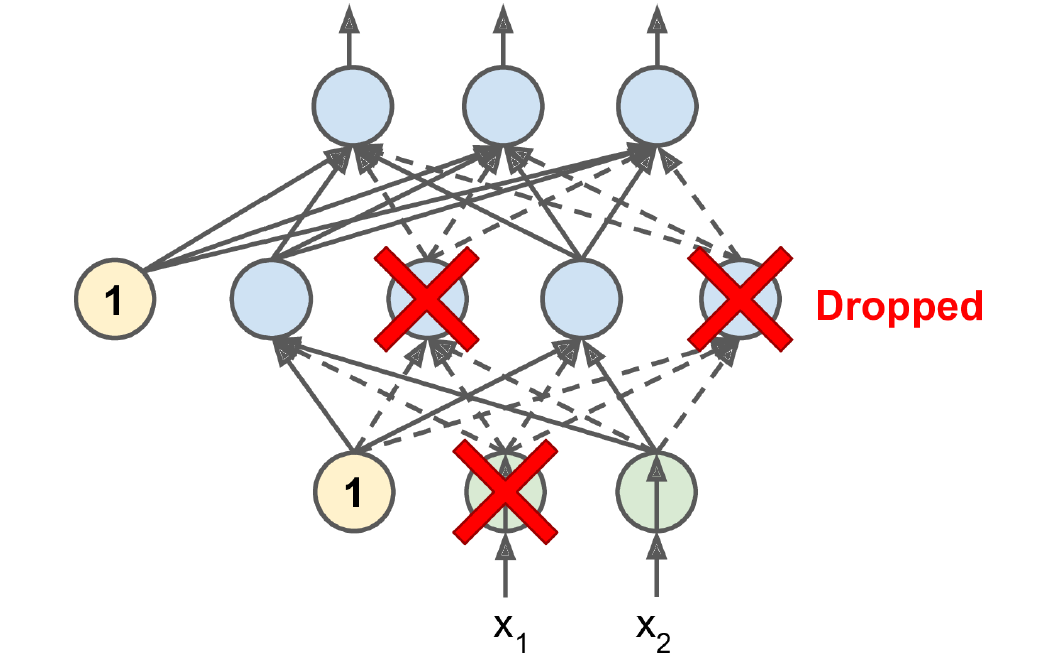

In [55]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid), verbose=2)

Epoch 1/2


1719/1719 - 11s - 6ms/step - accuracy: 0.8041 - loss: 0.5714 - val_accuracy: 0.8658 - val_loss: 0.3728


Epoch 2/2


1719/1719 - 9s - 5ms/step - accuracy: 0.8447 - loss: 0.4246 - val_accuracy: 0.8728 - val_loss: 0.3521


간단하게 더 살펴보자.

Dropout layer에 ```training=True```로 설정하여 값을 통과시키면 랜덤하게 일부가 0으로 설정되는 것을 볼 수 있다.

In [56]:
dropmodel = keras.models.Sequential([
    keras.layers.Input(shape=(5,)),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dropout(rate=0.5),
    keras.layers.Dense(3, activation="softmax")
])

In [57]:
output1 = dropmodel.layers[0](np.array([[1, 2, 3, 4, 5]]))
print(output1)

tf.Tensor(
[[0.         1.1361861  3.6815975  0.         0.         0.
  0.         0.         0.58098996 2.1473696 ]], shape=(1, 10), dtype=float32)


In [58]:
output2 = dropmodel.layers[1](output1, training=True)
print(output2)

tf.Tensor(
[[0.        0.        0.        0.        0.        0.        0.
  0.        1.1619799 0.       ]], shape=(1, 10), dtype=float32)


훈련이 아닐 경우에는 입력이 출력으로 그대로 전달된다.

In [59]:
print(dropmodel.layers[1](output1))

tf.Tensor(
[[0.         1.1361861  3.6815975  0.         0.         0.
  0.         0.         0.58098996 2.1473696 ]], shape=(1, 10), dtype=float32)


모델이 과대적합 되었다면 드롭아웃 비율을 늘릴 수 있다.  
반대로 모델이 과소적합 되었다면 드롭아웃 비율을 낮추어야 한다.  
층이 클 때는 드롭아웃 비율을 늘리고 작은 층에는 드롭아웃 비율을 낮추는 것도 도움이 된다.  
또한 많은 최신의 신경망 구조는 마지막 은닉층에만 드롭아웃을 사용하기도 한다.